# 불러오기

In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf



Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [ ]:
import pandas as pd
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings
import folium
import seaborn as sns
warnings.filterwarnings('ignore')
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] =False

In [ ]:

# 데이터 불러오기
df = pd.read_excel("/content/drive/MyDrive/소방안전/5m포함_최종데이터.xlsx")

In [ ]:
subset

,반경500m_수용가능인원합
0,10.0
1,0.0
2,0.0
3,10.0
4,35.0
...,...
10618,15.0
10619,0.0
10620,934.0
10621,934.0


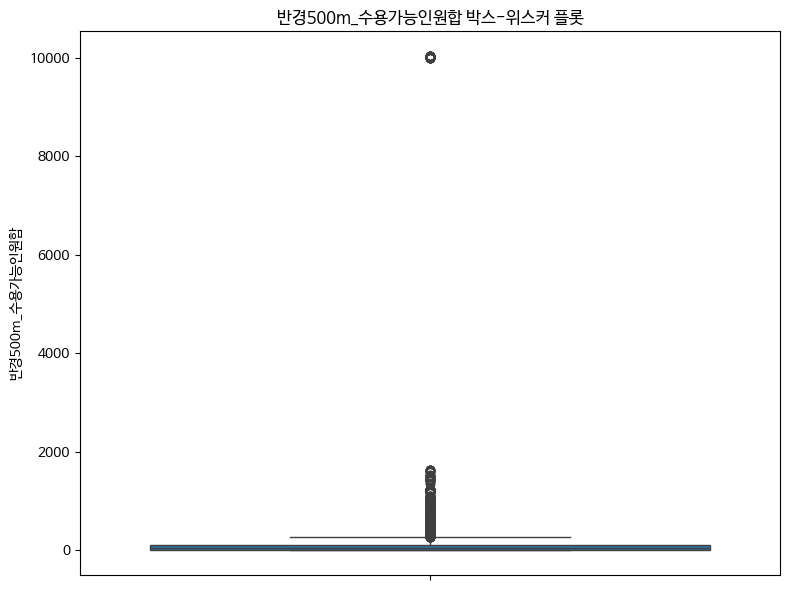

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# df는 이미지상의 subset DataFrame으로 가정
col_name = "반경500m_수용가능인원합"

plt.figure(figsize=(8, 6))
sns.boxplot(y=df[col_name], orient='v')
plt.title(f"{col_name} 박스-위스커 플롯")
plt.ylabel(col_name)
plt.xlabel("")  # x축 레이블은 제거
plt.tight_layout()
plt.show()


In [ ]:
df

,Unnamed: 0,표준버스정류장ID,버스정류장ARS번호,승차총승객수,하차총승객수,X좌표,Y좌표,정류소타입,승차_ID,총환승수,...,fused_temp,주택 노후도,count_buildings,열대야_일수,녹지존재,녹지면적,무더위쉼터 수,반경500m_수용가능인원합,geometry,5m 여부
0,0,100000001,1001,7495,9162,126.987752,37.569806,중앙차로,100000001.0,283.0,...,32.42437,5.368000,500,22,0,0.00,1,10.0,POINT (126.9877522923 37.5698055407),0
1,1,100000002,1002,30774,23105,126.996521,37.579433,중앙차로,100000002.0,8055.0,...,37.64027,3.477419,155,22,1,3113.44,0,0.0,POINT (126.9965206101 37.579432932),0
2,2,100000003,1003,58808,45242,126.998251,37.582580,중앙차로,100000003.0,9958.0,...,34.00820,3.918301,612,22,0,0.00,0,0.0,POINT (126.9982508372 37.5825800121),0
3,3,100000004,1004,12692,13906,126.987613,37.568579,중앙차로,100000004.0,2009.0,...,35.38950,5.555556,468,22,0,0.00,1,10.0,POINT (126.9876130976 37.5685792736),1
4,4,100000005,1005,25272,45827,127.001744,37.586243,중앙차로,100000005.0,6064.0,...,35.64396,4.003856,778,22,0,0.00,2,35.0,POINT (127.001744 37.586243),0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10618,10618,124900137,25682,4536,2136,127.147539,37.527911,마을버스,124900137.0,3134.0,...,38.01967,3.348837,129,20,0,0.00,1,15.0,POINT (127.1475394189 37.5279111948),1
10619,10619,124900138,25610,7428,4471,127.159941,37.565324,마을버스,124900138.0,58.0,...,32.69097,3.985294,68,15,0,0.00,0,0.0,POINT (127.159940671 37.5653235039),1
10620,10620,124900139,25611,954,476,127.156521,37.557835,마을버스,124900139.0,23.0,...,33.52497,3.754902,204,15,0,0.00,6,934.0,POINT (127.1565213227 37.557835126),1
10621,10621,124900140,25612,106,909,127.156821,37.556380,마을버스,124900140.0,57.0,...,33.71467,3.392857,84,15,1,1255.76,6,934.0,POINT (127.1568206916 37.5563795973),0


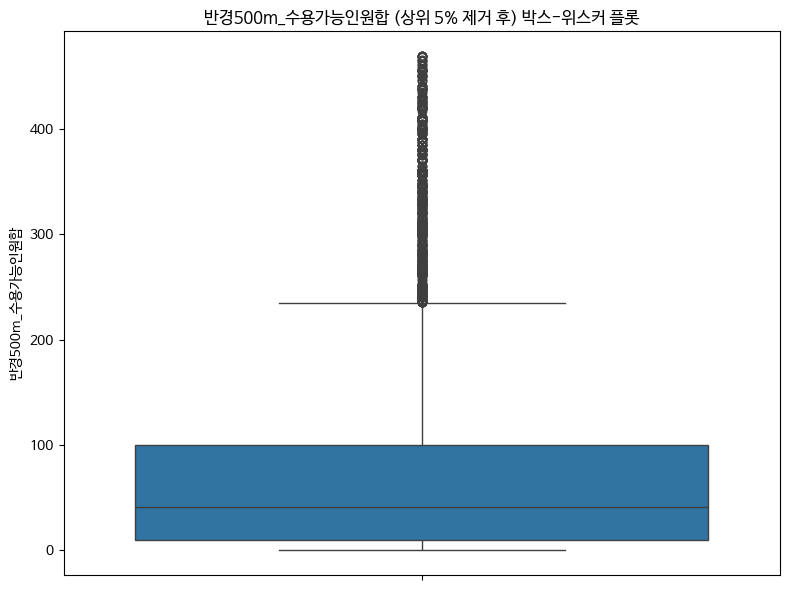

In [ ]:
import numpy as np

col = "반경500m_수용가능인원합"
# 상위 5% 기준값 계산
threshold = df[col].quantile(0.95)
# 상위 5% 제거한 데이터프레임
df_trimmed = df[df[col] <= threshold]

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(y=df_trimmed[col], orient='v')
plt.title(f"{col} (상위 5% 제거 후) 박스-위스커 플롯")
plt.ylabel(col)
plt.tight_layout()
plt.show()


In [ ]:
"""
shelter_df = pd.read_csv('/content/drive/MyDrive/소방안전/데이터/서울시 무더위쉼터.csv',encoding='cp949')
shelter_df = shelter_df[
    (shelter_df['시설구분1'] != '특정계층이용시설') |
    (
        (shelter_df['시설구분1'] == '특정계층이용시설') &
        (shelter_df['비고'] == '누구나 무더위쉼터 이용가능에 동의')
    )
].reset_index(drop=True)
"""

"\nshelter_df = pd.read_csv('/content/drive/MyDrive/소방안전/데이터/서울시 무더위쉼터.csv',encoding='cp949')\nshelter_df = shelter_df[\n    (shelter_df['시설구분1'] != '특정계층이용시설') |\n    (\n        (shelter_df['시설구분1'] == '특정계층이용시설') &\n        (shelter_df['비고'] == '누구나 무더위쉼터 이용가능에 동의')\n    )\n].reset_index(drop=True)\n"

## 무더위쉼터 컬럼 추가

In [ ]:
"""
import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree

# 데이터 불러오기
bus_df = df
shelter_filtered = shelter_df

# 위도, 경도 -> radians
bus_coords = np.radians(bus_df[["Y좌표", "X좌표"]].values)
shelter_coords = np.radians(shelter_filtered[["위도", "경도"]].values)
shelter_capacity = shelter_filtered["이용가능인원"].astype(float).values

# BallTree 구성
tree = BallTree(shelter_coords, metric='haversine')
radius = 500 / 6371000  # 500m in radians

# 반경 500m 내 인덱스 얻기
indices = tree.query_radius(bus_coords, r=radius)

# 각 정류장별 이용가능인원 합산
total_capacity = [shelter_capacity[idx].sum() for idx in indices]

# 결과 컬럼 추가
bus_df["반경500m_수용가능인원합"] = total_capacity
"""

'\nimport pandas as pd\nimport numpy as np\nfrom sklearn.neighbors import BallTree\n\n# 데이터 불러오기\nbus_df = df\nshelter_filtered = shelter_df\n\n# 위도, 경도 -> radians\nbus_coords = np.radians(bus_df[["Y좌표", "X좌표"]].values)\nshelter_coords = np.radians(shelter_filtered[["위도", "경도"]].values)\nshelter_capacity = shelter_filtered["이용가능인원"].astype(float).values\n\n# BallTree 구성\ntree = BallTree(shelter_coords, metric=\'haversine\')\nradius = 500 / 6371000  # 500m in radians\n\n# 반경 500m 내 인덱스 얻기\nindices = tree.query_radius(bus_coords, r=radius)\n\n# 각 정류장별 이용가능인원 합산\ntotal_capacity = [shelter_capacity[idx].sum() for idx in indices]\n\n# 결과 컬럼 추가\nbus_df["반경500m_수용가능인원합"] = total_capacity\n'

# Q 조정

## 필터링&스케일링

1. 필터링


80% 필터링


filtered_df

In [ ]:
# Q2 이상 필터링
columns_to_filter = ['승차총승객수', '총환승수', '가중평균환승시간']
q2_values = df[columns_to_filter].quantile(0.2)

filtered_df = df[
    (df['승차총승객수'] >= q2_values['승차총승객수']) &
    (df['총환승수'] >= q2_values['총환승수']) &
    (df['가중평균환승시간'] >= q2_values['가중평균환승시간'])
].reset_index(drop=True)





In [ ]:
# 표준화 대상 컬럼 지정 (예시: Step3~4에 활용될 지표 후보)
scale_cols = [
    '승차총승객수', '열대야_일수',
    'fused_temp', '자외선지수_평균', '주택 노후도', '녹지면적','저소득노인_비율','장애인_비율','국민기초_수급자비율',
    '반경500m_수용가능인원합'
]

# 결측치 제거
filtered_df = filtered_df.dropna(subset=scale_cols)



가장 봐줄만한 모양이 나온 standard 사용 결정

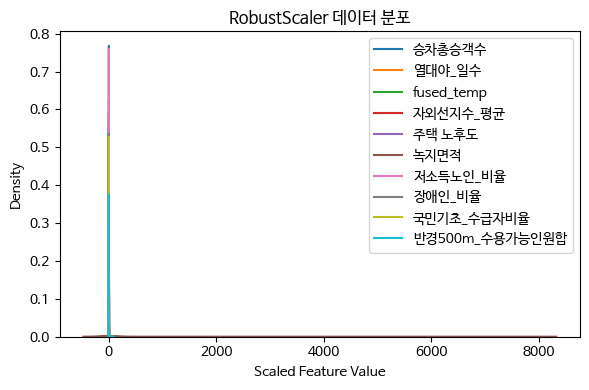

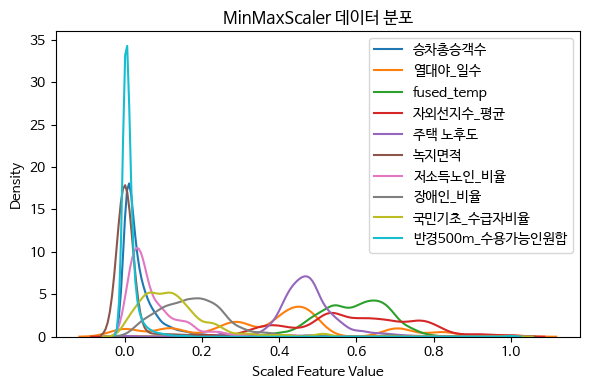

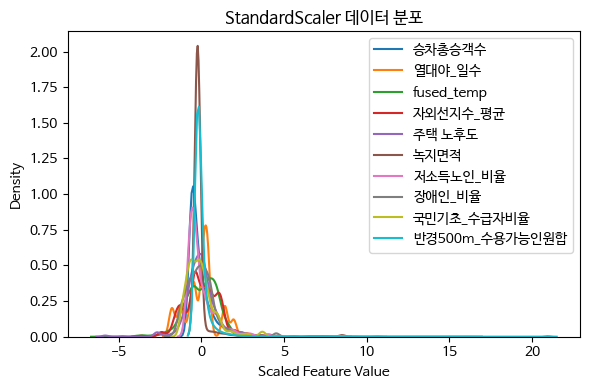

In [ ]:
selected_cols = ['승차총승객수', '열대야_일수',
    'fused_temp', '자외선지수_평균', '주택 노후도', '녹지면적','저소득노인_비율','장애인_비율','국민기초_수급자비율','반경500m_수용가능인원합']


# 스케일러 정의
scalers = {
    'RobustScaler': RobustScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'StandardScaler': StandardScaler()
}

# KDE plot 함수
def plot_kde_by_scaler(scaler_name, scaler, data, cols):
    scaled = scaler.fit_transform(data[cols])
    scaled_df = pd.DataFrame(scaled, columns=cols)

    plt.figure(figsize=(6, 4))
    for col in cols:
        sns.kdeplot(scaled_df[col], label=col)
    plt.title(f"{scaler_name} 데이터 분포")
    plt.xlabel("Scaled Feature Value")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 각각의 스케일러에 대해 KDE 플롯 출력
for scaler_name, scaler in scalers.items():
    plot_kde_by_scaler(scaler_name, scaler, filtered_df, selected_cols)

## 지표 계산


1.   Exposure
  1. 열대야_일수
  3. 자외선지수_평균
  4. fused_temp

2.   Sensitivity
  1.  주택 노후도
  2. 저소득노인_비율
  3. 장애인_비율
  4. 국민기초_수급자비율

3. Adaptive Capa
  1. 녹지면적
  2. 반경500m_수용가능인원합


In [ ]:

# 2. 지표별 변수 정의
exposure_cols = ['열대야_일수', '자외선지수_평균', 'fused_temp']
sensitivity_cols = ['주택 노후도', '저소득노인_비율', '장애인_비율', '국민기초_수급자비율']
adaptive_cols = ['녹지면적', '반경500m_수용가능인원합']
pop = ['승차총승객수']
all_cols = exposure_cols + sensitivity_cols + adaptive_cols+ pop


# 4. 표준화 (StandardScaler)
scaler = StandardScaler()
scaled = scaler.fit_transform(filtered_df[all_cols])
scaled_df = pd.DataFrame(scaled, columns=[f"{col}_std" for col in all_cols], index=filtered_df.index)

# 5. 원본 데이터에 결합
filtered_df = pd.concat([filtered_df, scaled_df], axis=1)

# 6. 지표별 평균 계산
filtered_df['Exposure'] = filtered_df[[f"{col}_std" for col in exposure_cols]].mean(axis=1)
filtered_df['Sensitivity'] = filtered_df[[f"{col}_std" for col in sensitivity_cols]].mean(axis=1)
filtered_df['Adaptive_Capacity'] = filtered_df[[f"{col}_std" for col in adaptive_cols]].mean(axis=1)

# 7. VRI 계산
filtered_df['VRI'] = ((filtered_df['Exposure'] + filtered_df['Sensitivity']) / 2 - filtered_df['Adaptive_Capacity']) / 2

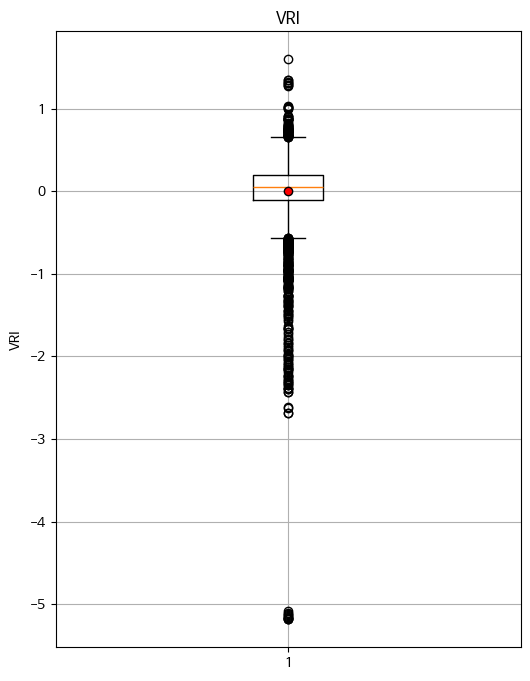

In [ ]:

import matplotlib.pyplot as plt


# NaN 제거 (건물이 없는 정류장 제외)
subset = filtered_df['VRI']

plt.figure(figsize=(6, 8))
plt.boxplot(subset, vert=True, showmeans=True, meanprops={"marker":"o", "markerfacecolor":"red", "markeredgecolor":"black"})
plt.title("VRI")
plt.ylabel("VRI")
plt.grid(True)
plt.show()


In [ ]:
filtered_df['최종지수'] = filtered_df['VRI']* 0.5 + filtered_df['승차총승객수']*0.5
filtered_df['최종지수']

,최종지수
0,3747.686548
1,6346.238118
2,3880.515103
3,9630.965907
4,1337.011295
...,...
5906,377.276041
5907,1896.667042
5908,395.171260
5909,3713.790229


In [ ]:
df_cluster = filtered_df[['표준버스정류장ID','Exposure','Sensitivity','Adaptive_Capacity','승차총승객수','최종지수']]
df_cluster

,표준버스정류장ID,Exposure,Sensitivity,Adaptive_Capacity,승차총승객수,최종지수
0,100000001,-0.650965,1.653685,-0.244831,7495,3747.686548
1,100000004,-0.310634,1.725914,-0.244831,12692,6346.238118
2,100000006,-0.298405,0.225847,-0.096693,7761,3880.515103
3,100000007,-0.698761,0.232628,-0.096693,19262,9630.965907
4,100000008,-0.298405,0.195379,-0.096693,2674,1337.011295
...,...,...,...,...,...,...
5906,124900121,-1.513155,-0.584515,1.847001,756,377.276041
5907,124900123,-1.238300,-0.727807,0.348779,3794,1896.667042
5908,124900124,-1.238300,-0.694063,0.348779,791,395.171260
5909,124900138,-1.889273,-0.299719,-0.255412,7428,3713.790229


## 클러스터링

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 클러스터링 대상 변수 지정
features = ['Exposure', 'Sensitivity', 'Adaptive_Capacity', '승차총승객수']
X = df_cluster[features].values

# 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA 2차원 축소 (시각화용)
X_pca = PCA(n_components=2).fit_transform(X_scaled)

# 실루엣 계수로 최적 k 찾기 (KMeans 기준)
sil_scores = []
k_range = range(2, 11)
for k in k_range:
    labels = KMeans(n_clusters=k, random_state=42).fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

best_k = k_range[np.argmax(sil_scores)]



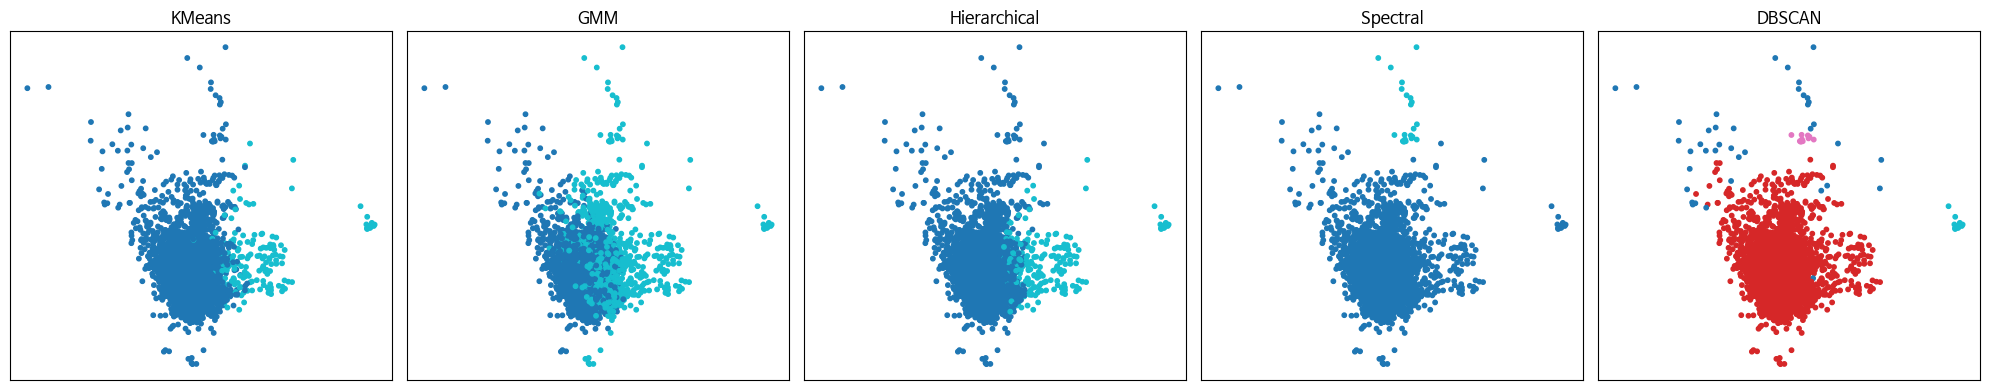


▶ KMeans 클러스터별 최종지수 평균:
KMeans
0    3245.678854
1    2178.478416
Name: 최종지수, dtype: float64

▶ GMM 클러스터별 최종지수 평균:
GMM
0    3410.959858
1    2517.528927
Name: 최종지수, dtype: float64

▶ Hierarchical 클러스터별 최종지수 평균:
Hierarchical
0    3248.044698
1    2360.672803
Name: 최종지수, dtype: float64

▶ Spectral 클러스터별 최종지수 평균:
Spectral
0    3217.011269
1    2906.440952
Name: 최종지수, dtype: float64

▶ DBSCAN 클러스터별 최종지수 평균:
DBSCAN
-1    23744.896501
 0     3078.025277
 2     1572.472479
 1     1553.774016
Name: 최종지수, dtype: float64


In [ ]:
# 클러스터링 알고리즘별 수행
df_cluster['KMeans'] = KMeans(n_clusters=best_k, random_state=42).fit_predict(X_scaled)
df_cluster['GMM'] = GaussianMixture(n_components=best_k, random_state=42).fit_predict(X_scaled)
df_cluster['Hierarchical'] = AgglomerativeClustering(n_clusters=best_k).fit_predict(X_scaled)
df_cluster['Spectral'] = SpectralClustering(n_clusters=best_k, affinity='nearest_neighbors', random_state=42).fit_predict(X_scaled)
df_cluster['DBSCAN'] = DBSCAN(eps=1.5, min_samples=10).fit_predict(X_scaled)

# 클러스터 시각화
methods = ['KMeans', 'GMM', 'Hierarchical', 'Spectral', 'DBSCAN']
fig, axes = plt.subplots(1, len(methods), figsize=(20, 4))
for i, method in enumerate(methods):
    axes[i].scatter(X_pca[:, 0], X_pca[:, 1], c=df_cluster[method], cmap='tab10', s=10)
    axes[i].set_title(method)
    axes[i].set_xticks([])
    axes[i].set_yticks([])
plt.tight_layout()
plt.show()

# 클러스터별 최종지수 평균 계산
for method in methods:
    print(f"\n▶ {method} 클러스터별 최종지수 평균:")
    print(df_cluster.groupby(method)['최종지수'].mean().sort_values(ascending=False))


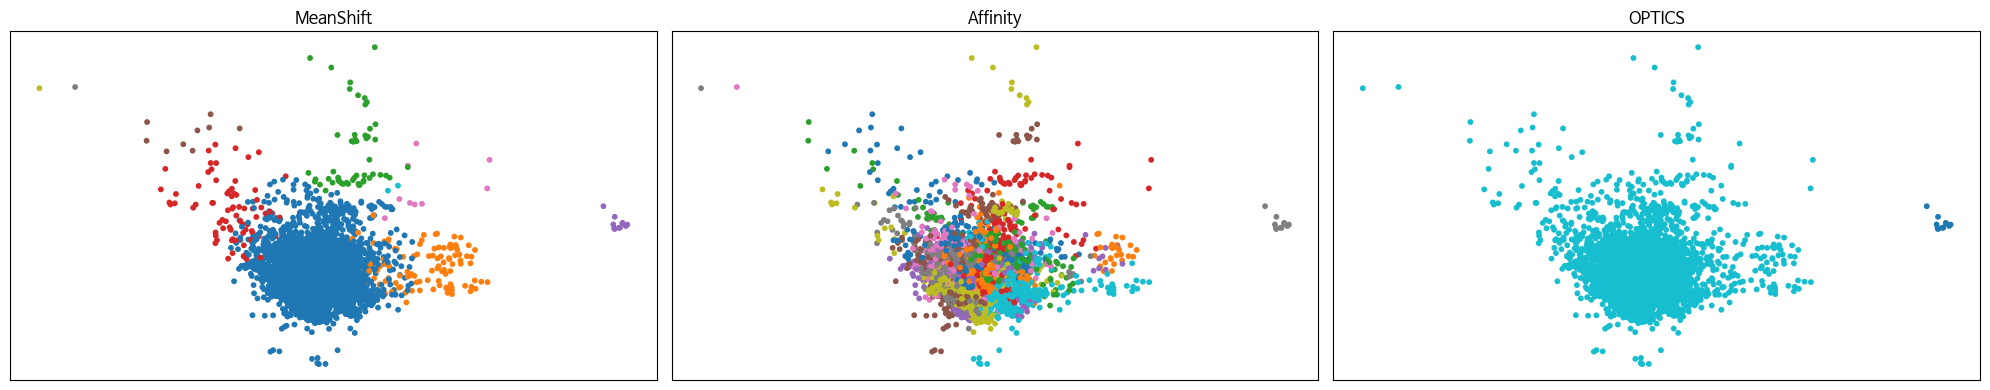


▶ MeanShift 클러스터별 최종지수 평균:
MeanShift
8    73556.942953
7    61385.647807
5    38269.261666
3    23889.713427
9    15508.437992
0     2885.323718
2     2142.435371
6     2017.576037
1     1710.639035
4     1572.472479
Name: 최종지수, dtype: float64

▶ Affinity 클러스터별 최종지수 평균:
Affinity
144    73556.942953
127    61385.647807
14     42772.015098
37     41525.335464
164    35641.433253
           ...     
78       695.231532
179      681.328771
45       612.363452
61       609.319224
55       565.404382
Name: 최종지수, Length: 184, dtype: float64

▶ OPTICS 클러스터별 최종지수 평균:
OPTICS
 0    3219.021338
-1    1572.472479
Name: 최종지수, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

methods = [ 'MeanShift', 'Affinity', 'OPTICS']


from sklearn.cluster import MeanShift

ms = MeanShift(bin_seeding=True)
ms_labels = ms.fit_predict(X_scaled)
df_cluster['MeanShift'] = ms_labels


from sklearn.cluster import AffinityPropagation

ap = AffinityPropagation(random_state=42, affinity='euclidean')
df_cluster['Affinity'] = ap.fit_predict(X_scaled)

from sklearn.cluster import OPTICS

optics = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.05)
df_cluster['OPTICS'] = optics.fit_predict(X_scaled)



fig, axes = plt.subplots(1, len(methods), figsize=(20, 4))
for ax, method in zip(axes, methods):
    sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=df_cluster[method], cmap='tab10', s=10)
    ax.set_title(method)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

# 각 클러스터링 기법별 '최종지수' 평균
for method in methods:
    print(f"\n▶ {method} 클러스터별 최종지수 평균:")
    print(df_cluster.groupby(method)['최종지수'].mean().sort_values(ascending=False))


In [ ]:
df_cluster[df_cluster['MeanShift']==8]

,표준버스정류장ID,Exposure,Sensitivity,Adaptive_Capacity,승차총승객수,최종지수,KMeans,GMM,Hierarchical,Spectral,DBSCAN,MeanShift,Affinity,OPTICS
4741,121000012,-0.282066,-0.630108,-0.227901,147114,73556.942953,0,0,0,0,-1,8,144,0


# Q 조정_minmax

---




## 필터링&스케일링

1. 필터링


80% 필터링


filtered_df

In [ ]:
# Step1: Q2 이상 필터링
columns_to_filter = ['승차총승객수', '총환승수', '가중평균환승시간']
q2_values = df[columns_to_filter].quantile(0.2)

filtered_df = df[
    (df['승차총승객수'] >= q2_values['승차총승객수']) &
    (df['총환승수'] >= q2_values['총환승수']) &
    (df['가중평균환승시간'] >= q2_values['가중평균환승시간'])
].reset_index(drop=True)





In [ ]:
# Step2: 표준화 대상 컬럼 지정 (예시: Step3~4에 활용될 지표 후보)
scale_cols = [
    '승차총승객수', '열대야_일수',
    'fused_temp', '자외선지수_평균', '주택 노후도', '녹지면적','저소득노인_비율','장애인_비율','국민기초_수급자비율',
    '반경500m_수용가능인원합'
]

# 결측치 제거
filtered_df = filtered_df.dropna(subset=scale_cols)



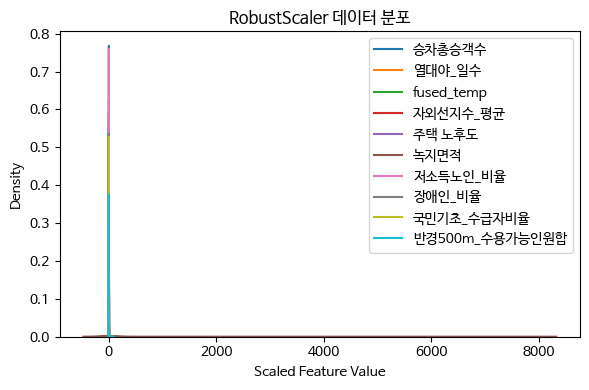

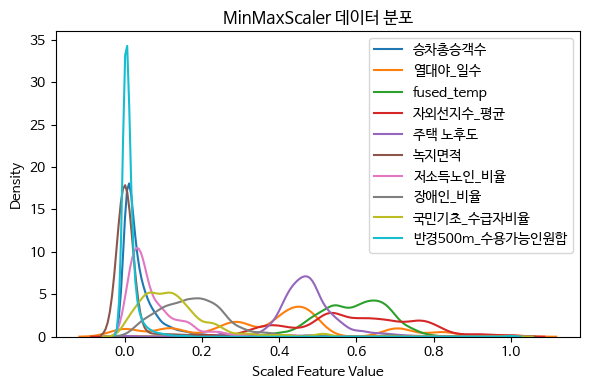

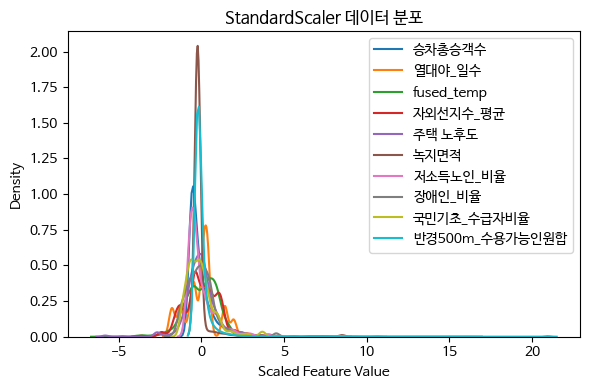

In [ ]:
selected_cols = ['승차총승객수', '열대야_일수',
    'fused_temp', '자외선지수_평균', '주택 노후도', '녹지면적','저소득노인_비율','장애인_비율','국민기초_수급자비율','반경500m_수용가능인원합']


# 스케일러 정의
scalers = {
    'RobustScaler': RobustScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'StandardScaler': StandardScaler()
}

# KDE plot 함수
def plot_kde_by_scaler(scaler_name, scaler, data, cols):
    scaled = scaler.fit_transform(data[cols])
    scaled_df = pd.DataFrame(scaled, columns=cols)

    plt.figure(figsize=(6, 4))
    for col in cols:
        sns.kdeplot(scaled_df[col], label=col)
    plt.title(f"{scaler_name} 데이터 분포")
    plt.xlabel("Scaled Feature Value")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 각각의 스케일러에 대해 KDE 플롯 출력
for scaler_name, scaler in scalers.items():
    plot_kde_by_scaler(scaler_name, scaler, filtered_df, selected_cols)

## 지표 계산


1.   Exposure
  1. 열대야_일수
  3. 자외선지수_평균
  4. fused_temp

2.   Sensitivity
  1.  주택 노후도
  2. 저소득노인_비율
  3. 장애인_비율
  4. 국민기초_수급자비율

3. Adaptive Capa
  1. 녹지면적
  2. 반경500m_수용가능인원합


In [ ]:

# 2. 지표별 변수 정의
exposure_cols = ['열대야_일수', '자외선지수_평균', 'fused_temp']
sensitivity_cols = ['주택 노후도', '저소득노인_비율', '장애인_비율', '국민기초_수급자비율']
adaptive_cols = ['녹지면적', '반경500m_수용가능인원합']
pop = ['승차총승객수']
all_cols = exposure_cols + sensitivity_cols + adaptive_cols+ pop


# 4. 표준화 (StandardScaler)
scaler = MinMaxScaler()
scaled = scaler.fit_transform(filtered_df[all_cols])
scaled_df = pd.DataFrame(scaled, columns=[f"{col}_std" for col in all_cols], index=filtered_df.index)

# 5. 원본 데이터에 결합
filtered_df = pd.concat([filtered_df, scaled_df], axis=1)

# 6. 지표별 평균 계산
filtered_df['Exposure'] = filtered_df[[f"{col}_std" for col in exposure_cols]].mean(axis=1)
filtered_df['Sensitivity'] = filtered_df[[f"{col}_std" for col in sensitivity_cols]].mean(axis=1)
filtered_df['Adaptive_Capacity'] = filtered_df[[f"{col}_std" for col in adaptive_cols]].mean(axis=1)

# 7. VRI 계산
filtered_df['VRI'] = ((filtered_df['Exposure'] + filtered_df['Sensitivity']) / 2 - filtered_df['Adaptive_Capacity']) / 2

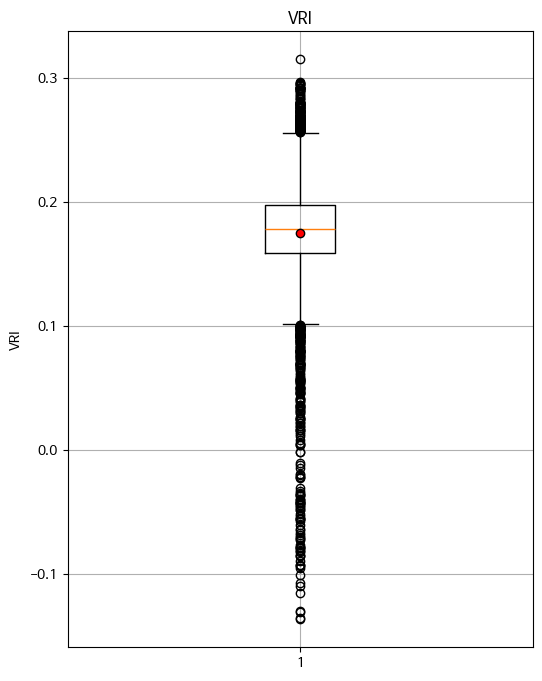

In [ ]:


import matplotlib.pyplot as plt

# final_df 예시
# final_df = pd.DataFrame({
#     'stop_id': [...],
#     'mean_old_level': [...],
# })

# NaN 제거 (건물이 없는 정류장 제외)
subset = filtered_df['VRI']

plt.figure(figsize=(6, 8))
plt.boxplot(subset, vert=True, showmeans=True, meanprops={"marker":"o", "markerfacecolor":"red", "markeredgecolor":"black"})
plt.title("VRI")
plt.ylabel("VRI")
plt.grid(True)
plt.show()


In [ ]:
filtered_df['최종지수'] = filtered_df['VRI']* 0.5 + filtered_df['승차총승객수_std']*0.5
filtered_df['최종지수']

,최종지수
0,0.126944
1,0.149491
2,0.111468
3,0.145955
4,0.093807
...,...
5906,0.009621
5907,0.060048
5908,0.050150
5909,0.073273


In [ ]:
df_where = df[['표준버스정류장ID','X좌표','Y좌표']]
df_where

,표준버스정류장ID,X좌표,Y좌표
0,100000001,126.987752,37.569806
1,100000002,126.996521,37.579433
2,100000003,126.998251,37.582580
3,100000004,126.987613,37.568579
4,100000005,127.001744,37.586243
...,...,...,...
10618,124900137,127.147539,37.527911
10619,124900138,127.159941,37.565324
10620,124900139,127.156521,37.557835
10621,124900140,127.156821,37.556380


In [ ]:
df_cluster = filtered_df[['표준버스정류장ID','Exposure','Sensitivity','Adaptive_Capacity','승차총승객수_std','최종지수']]
df_cluster = pd.concat([df_cluster,df_where],axis=1)
df_cluster =df_cluster.dropna()
df_cluster

,표준버스정류장ID,Exposure,Sensitivity,Adaptive_Capacity,승차총승객수_std,최종지수,표준버스정류장ID,X좌표,Y좌표
0,100000001.0,0.451840,0.374046,0.000498,0.047665,0.126944,100000001,126.987752,37.569806
1,100000004.0,0.484525,0.379947,0.000498,0.083113,0.149491,100000002,126.996521,37.579433
2,100000006.0,0.478510,0.230258,0.007472,0.049479,0.111468,100000003,126.998251,37.582580
3,100000007.0,0.440060,0.230812,0.007472,0.127927,0.145955,100000004,126.987613,37.568579
4,100000008.0,0.478510,0.227769,0.007472,0.014781,0.093807,100000005,127.001744,37.586243
...,...,...,...,...,...,...,...,...,...
5906,124900121.0,0.253175,0.158948,0.170973,0.001698,0.009621,114900042,126.868808,37.540239
5907,124900123.0,0.303535,0.144053,0.028445,0.022420,0.060048,114900044,126.831971,37.540197
5908,124900124.0,0.303535,0.146809,0.028445,0.001937,0.050150,114900047,126.871333,37.546695
5909,124900138.0,0.212260,0.185090,0.000000,0.047208,0.073273,114900048,126.842581,37.518745


## 클러스터링

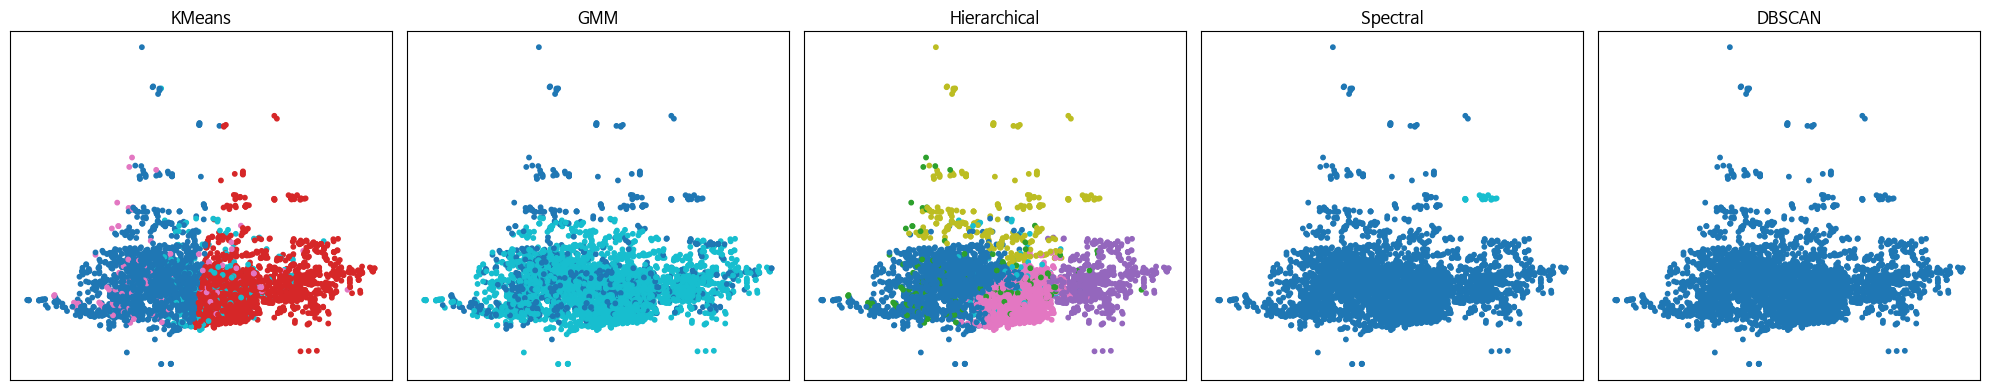


▶ KMeans 클러스터별 최종지수 평균:
KMeans
3    0.198875
1    0.115498
0    0.094112
2    0.014394
Name: 최종지수, dtype: float64

▶ GMM 클러스터별 최종지수 평균:
GMM
1    0.112095
0    0.089298
Name: 최종지수, dtype: float64

▶ Hierarchical 클러스터별 최종지수 평균:
Hierarchical
5    0.266220
2    0.133799
4    0.125476
3    0.111205
0    0.097340
1    0.031690
Name: 최종지수, dtype: float64

▶ Spectral 클러스터별 최종지수 평균:
Spectral
1    0.150019
0    0.107730
Name: 최종지수, dtype: float64

▶ DBSCAN 클러스터별 최종지수 평균:
DBSCAN
0    0.107928
Name: 최종지수, dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 클러스터링 대상 변수 지정
features = ['Exposure', 'Sensitivity', 'Adaptive_Capacity', '승차총승객수_std']
X = df_cluster[features].values

# 정규화
scaler = StandardScaler()
X_scaled = X

# PCA 2차원 축소 (시각화용)
X_pca = PCA(n_components=2).fit_transform(X_scaled)

results = {}

# 2. KMeans + GMM + Hierarchical + Spectral: 실루엣 기반 최적 k 탐색
k_range = range(2, 11)
sil_k = {method: [] for method in ['KMeans', 'GMM', 'Hierarchical', 'Spectral']}

for k in k_range:
    # KMeans
    labels = KMeans(n_clusters=k, random_state=42).fit_predict(X_scaled)
    sil_k['KMeans'].append(silhouette_score(X_scaled, labels))
    # GMM
    labels = GaussianMixture(n_components=k, random_state=42).fit_predict(X_scaled)
    sil_k['GMM'].append(silhouette_score(X_scaled, labels))
    # Hierarchical
    labels = AgglomerativeClustering(n_clusters=k).fit_predict(X_scaled)
    sil_k['Hierarchical'].append(silhouette_score(X_scaled, labels))
    # Spectral
    labels = SpectralClustering(n_clusters=k, affinity='nearest_neighbors', random_state=42).fit_predict(X_scaled)
    sil_k['Spectral'].append(silhouette_score(X_scaled, labels))

# 최적 k와 점수 저장
for method in sil_k:
    best_idx = np.argmax(sil_k[method])
    best_k = k_range[best_idx]
    results[method] = (best_k, sil_k[method][best_idx])


"""
# 실루엣 계수로 최적 k 찾기 (KMeans 기준)
sil_scores = []
k_range = range(2, 11)
for k in k_range:
    labels = KMeans(n_clusters=k, random_state=42).fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

best_k = k_range[np.argmax(sil_scores)]
"""

# 클러스터링 알고리즘별 수행
df_cluster['KMeans'] = KMeans(n_clusters=results['KMeans'][0], random_state=42).fit_predict(X_scaled)
df_cluster['GMM'] = GaussianMixture(n_components=results['GMM'][0], random_state=42).fit_predict(X_scaled)
df_cluster['Hierarchical'] = AgglomerativeClustering(n_clusters=results['Hierarchical'][0]).fit_predict(X_scaled)
df_cluster['Spectral'] = SpectralClustering(n_clusters=results['Spectral'][0], affinity='nearest_neighbors', random_state=42).fit_predict(X_scaled)
df_cluster['DBSCAN'] = DBSCAN(eps=1.5, min_samples=10).fit_predict(X_scaled)

# 클러스터 시각화
methods = ['KMeans', 'GMM', 'Hierarchical', 'Spectral', 'DBSCAN']
fig, axes = plt.subplots(1, len(methods), figsize=(20, 4))
for i, method in enumerate(methods):
    axes[i].scatter(X_pca[:, 0], X_pca[:, 1], c=df_cluster[method], cmap='tab10', s=10)
    axes[i].set_title(method)
    axes[i].set_xticks([])
    axes[i].set_yticks([])
plt.tight_layout()
plt.show()

# 클러스터별 최종지수 평균 계산
for method in methods:
    print(f"\n▶ {method} 클러스터별 최종지수 평균:")
    print(df_cluster.groupby(method)['최종지수'].mean().sort_values(ascending=False))




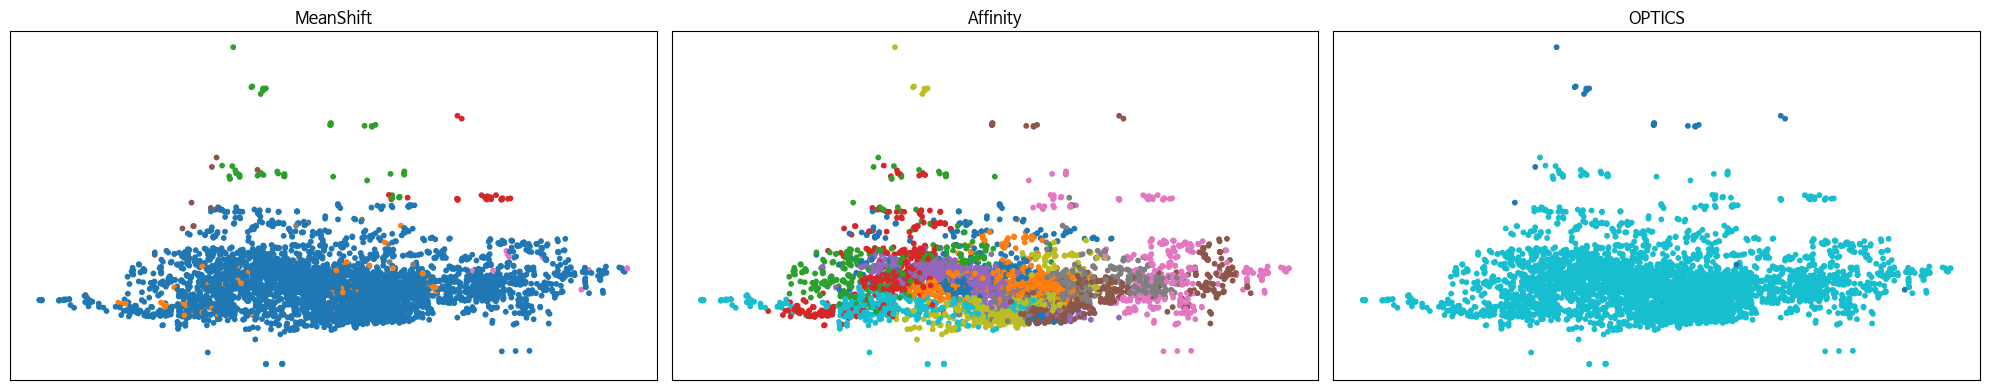


▶ MeanShift 클러스터별 최종지수 평균:
MeanShift
7    0.582866
6    0.362671
3    0.147766
2    0.138412
0    0.108699
5    0.099082
8    0.095739
4    0.036166
1   -0.004075
Name: 최종지수, dtype: float64

▶ Affinity 클러스터별 최종지수 평균:
Affinity
126    0.582866
109    0.522242
30     0.385150
38     0.335412
121    0.330197
         ...   
120   -0.010243
148   -0.013858
41    -0.017462
23    -0.025515
145   -0.047612
Name: 최종지수, Length: 150, dtype: float64

▶ OPTICS 클러스터별 최종지수 평균:
OPTICS
-1    0.177870
 0    0.107587
Name: 최종지수, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

methods = [ 'MeanShift', 'Affinity', 'OPTICS']


from sklearn.cluster import MeanShift

ms = MeanShift(bin_seeding=True)
ms_labels = ms.fit_predict(X_scaled)
df_cluster['MeanShift'] = ms_labels


from sklearn.cluster import AffinityPropagation

ap = AffinityPropagation(random_state=42, affinity='euclidean')
df_cluster['Affinity'] = ap.fit_predict(X_scaled)

from sklearn.cluster import OPTICS

optics = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.05)
df_cluster['OPTICS'] = optics.fit_predict(X_scaled)



fig, axes = plt.subplots(1, len(methods), figsize=(20, 4))
for ax, method in zip(axes, methods):
    sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=df_cluster[method], cmap='tab10', s=10)
    ax.set_title(method)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

# 각 클러스터링 기법별 '최종지수' 평균
for method in methods:
    print(f"\n▶ {method} 클러스터별 최종지수 평균:")
    print(df_cluster.groupby(method)['최종지수'].mean().sort_values(ascending=False))


In [ ]:
df_cluster

,표준버스정류장ID,Exposure,Sensitivity,Adaptive_Capacity,승차총승객수_std,최종지수,표준버스정류장ID,X좌표,Y좌표,KMeans,GMM,Hierarchical,Spectral,DBSCAN,MeanShift,Affinity,OPTICS
0,100000001.0,0.451840,0.374046,0.000498,0.047665,0.126944,100000001,126.987752,37.569806,0,1,4,0,0,0,51,0
1,100000004.0,0.484525,0.379947,0.000498,0.083113,0.149491,100000002,126.996521,37.579433,0,1,4,0,0,0,4,0
2,100000006.0,0.478510,0.230258,0.007472,0.049479,0.111468,100000003,126.998251,37.582580,0,1,0,0,0,0,0,0
3,100000007.0,0.440060,0.230812,0.007472,0.127927,0.145955,100000004,126.987613,37.568579,0,1,0,0,0,0,62,0
4,100000008.0,0.478510,0.227769,0.007472,0.014781,0.093807,100000005,127.001744,37.586243,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5906,124900121.0,0.253175,0.158948,0.170973,0.001698,0.009621,114900042,126.868808,37.540239,0,0,0,0,0,0,149,0
5907,124900123.0,0.303535,0.144053,0.028445,0.022420,0.060048,114900044,126.831971,37.540197,0,0,0,0,0,0,57,0
5908,124900124.0,0.303535,0.146809,0.028445,0.001937,0.050150,114900047,126.871333,37.546695,0,0,0,0,0,0,57,0
5909,124900138.0,0.212260,0.185090,0.000000,0.047208,0.073273,114900048,126.842581,37.518745,0,1,0,0,0,0,147,0


## 시각화

In [ ]:
import folium
cluster_means = df_cluster.groupby('MeanShift')['최종지수'].mean()
best_cluster = cluster_means.idxmax()

# 3. 해당 클러스터 소속 정류장 중 '최종지수' 최대값 정류장 선택
best_station = df_cluster[df_cluster['MeanShift'] == best_cluster].loc[
    df_cluster['최종지수'].idxmax()
]

# 좌표 추출 (Y: 위도, X: 경도)
lat, lon = best_station['Y좌표'], best_station['X좌표']

# 4. Folium 지도 생성
m = folium.Map(location=[lat, lon], zoom_start=16, tiles="OpenStreetMap")


# 중심 정류장 마커 강조
folium.Marker(
    location=[lat, lon],
    popup=f"Best Station\nID: {best_station['표준버스정류장ID']}\n평균 최종지수: {cluster_means[best_cluster]:.1f}",
    icon=folium.Icon(color='red', icon='star')
).add_to(m)

# 5. 반경 400m 원 그리기
folium.Circle(
    location=[lat, lon],
    radius=400,  # 단위: meters
    color='red',
    weight=2,
    fill=False
).add_to(m)

m

In [ ]:
import folium
import pandas as pd
import matplotlib.pyplot as plt
from folium.plugins import MarkerCluster
from matplotlib import cm

# ─ 1) MeanShift 클러스터별로 최종지수 최대값을 가진 행 추출 ─
top_by_cluster = (
    df_cluster[['표준버스정류장ID', 'Y좌표', 'X좌표', 'MeanShift', '최종지수']]
    .groupby('MeanShift', dropna=False, as_index=False)
    .apply(lambda grp: grp.loc[grp['최종지수'].idxmax()])
    .reset_index(drop=True)
)

# ─ 2) 지도의 중심 좌표 설정
center_lat = df_cluster['Y좌표'].mean()
center_lon = df_cluster['X좌표'].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles='OpenStreetMap')


# ─ 4) 각 클러스터의 정류장만 지도에 표시
for _, row in top_by_cluster.iterrows():
    folium.CircleMarker(
        location=[row['Y좌표'], row['X좌표']],
        radius=6,
        fill=True,
        fill_opacity=0.9,
        popup=(f"ID: {row['표준버스정류장ID']}<br>"
               f"클러스터: {row['MeanShift']}<br>"
               f"최종지수: {row['최종지수']:.2f}")
    ).add_to(m)

# ─ (선택) 레이어 추가 및 지도 보여주기
m.add_child(folium.LayerControl())

# Jupyter 사용자라면 아래로 출력
display(m)

In [ ]:
import folium
from folium.plugins import MarkerCluster
import pandas as pd

# --- ① 표시할 클러스터링 기법
methods = ['KMeans', 'GMM', 'Hierarchical', 'Spectral', 'MeanShift', 'Affinity', 'OPTICS']

# --- ② 각 기법별: 클러스터별 최종지수 최고 정류장만 추출
top_by_method = {}
for m in methods:
    if m not in df_cluster.columns:
        continue
    df_m = (
        df_cluster
        [[ '표준버스정류장ID', 'Y좌표', 'X좌표', m, '최종지수' ]]
        .dropna(subset=[m, '최종지수'])
    )
    idxs = df_m.groupby(m)['최종지수'].idxmax()
    top_by_method[m] = df_m.loc[idxs].reset_index(drop=True)

# --- ③ 지도 중심 설정 (전체 평균 위치)
center_lat = df_cluster['Y좌표'].mean()
center_lon = df_cluster['X좌표'].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles='OpenStreetMap')

# --- ④ 기법별 색상을 직접 지정
method_colors = {
    'KMeans': 'red',
    'GMM': 'orange',
    'Hierarchical': 'green',
    'Spectral': 'purple',
    'MeanShift': 'blue',
    'Affinity': 'yellow',
    'OPTICS': 'darkred'
}

# --- ⑤ 기법별 MarkerCluster로 마커 추가
for mtd, df_top in top_by_method.items():
    cluster = MarkerCluster(name=mtd).add_to(m)
    color = method_colors.get(mtd, 'black')
    for _, row in df_top.iterrows():
        folium.CircleMarker(
            location=[row['Y좌표'], row['X좌표']],
            radius=7,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.8,
            popup=(
                f"<b>방식:</b> {mtd}<br>"
                f"클러스터: {row[mtd]}<br>"
                f"ID: {row['표준버스정류장ID']}<br>"
                f"최종지수: {row['최종지수']:.3f}"
            )
        ).add_to(cluster)

# --- ⑥ Layer control (지도 상에서 기법별 표시 토글)
folium.LayerControl(collapsed=False).add_to(m)

# 지도 출력 (Jupyter 환경에서만 가능)
display(m)

# (원한다면 아래로 HTML 파일로 저장)
# m.save("top_최종지수_by_cluster_method.html")


# Q 조정_standard


---




## 필터링&스케일링

1. 필터링


80% 필터링


filtered_df

In [ ]:
# Step1: Q2 이상 필터링
columns_to_filter = ['승차총승객수', '총환승수', '가중평균환승시간']
q2_values = df[columns_to_filter].quantile(0.2)

filtered_df = df[
    (df['승차총승객수'] >= q2_values['승차총승객수']) &
    (df['총환승수'] >= q2_values['총환승수']) &
    (df['가중평균환승시간'] >= q2_values['가중평균환승시간'])
].reset_index(drop=True)





In [ ]:
# Step2: 표준화 대상 컬럼 지정 (예시: Step3~4에 활용될 지표 후보)
scale_cols = [
    '승차총승객수', '열대야_일수',
    'fused_temp', '자외선지수_평균', '주택 노후도', '녹지면적','저소득노인_비율','장애인_비율','국민기초_수급자비율',
    '반경500m_수용가능인원합'
]

# 결측치 제거
filtered_df = filtered_df.dropna(subset=scale_cols)



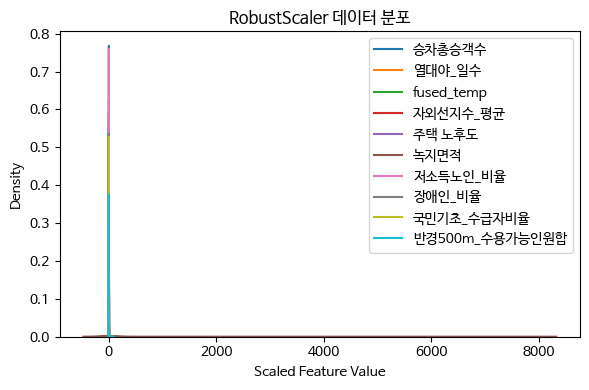

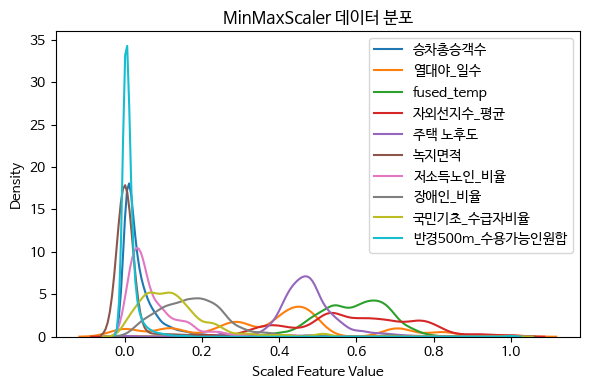

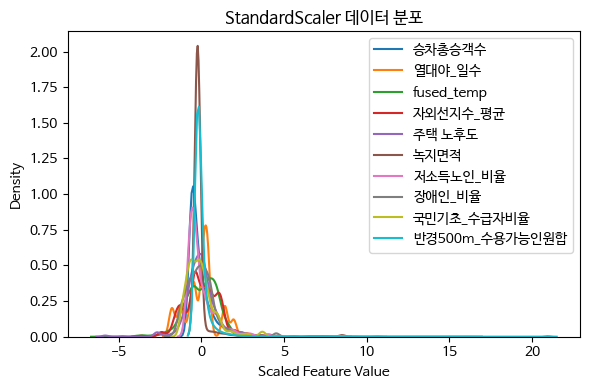

In [ ]:
selected_cols = ['승차총승객수', '열대야_일수',
    'fused_temp', '자외선지수_평균', '주택 노후도', '녹지면적','저소득노인_비율','장애인_비율','국민기초_수급자비율','반경500m_수용가능인원합']


# 스케일러 정의
scalers = {
    'RobustScaler': RobustScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'StandardScaler': StandardScaler()
}

# KDE plot 함수
def plot_kde_by_scaler(scaler_name, scaler, data, cols):
    scaled = scaler.fit_transform(data[cols])
    scaled_df = pd.DataFrame(scaled, columns=cols)

    plt.figure(figsize=(6, 4))
    for col in cols:
        sns.kdeplot(scaled_df[col], label=col)
    plt.title(f"{scaler_name} 데이터 분포")
    plt.xlabel("Scaled Feature Value")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 각각의 스케일러에 대해 KDE 플롯 출력
for scaler_name, scaler in scalers.items():
    plot_kde_by_scaler(scaler_name, scaler, filtered_df, selected_cols)

## 지표 계산


1.   Exposure
  1. 열대야_일수
  3. 자외선지수_평균
  4. fused_temp

2.   Sensitivity
  1.  주택 노후도
  2. 저소득노인_비율
  3. 장애인_비율
  4. 국민기초_수급자비율

3. Adaptive Capa
  1. 녹지면적
  2. 반경500m_수용가능인원합


In [ ]:

# 2. 지표별 변수 정의
exposure_cols = ['열대야_일수', '자외선지수_평균', 'fused_temp']
sensitivity_cols = ['주택 노후도', '저소득노인_비율', '장애인_비율', '국민기초_수급자비율']
adaptive_cols = ['녹지면적', '반경500m_수용가능인원합']
pop = ['승차총승객수']
all_cols = exposure_cols + sensitivity_cols + adaptive_cols+ pop


# 4. 표준화 (StandardScaler)
scaler = StandardScaler()
scaled = scaler.fit_transform(filtered_df[all_cols])
scaled_df = pd.DataFrame(scaled, columns=[f"{col}_std" for col in all_cols], index=filtered_df.index)

# 5. 원본 데이터에 결합
filtered_df = pd.concat([filtered_df, scaled_df], axis=1)

# 6. 지표별 평균 계산
filtered_df['Exposure'] = filtered_df[[f"{col}_std" for col in exposure_cols]].mean(axis=1)
filtered_df['Sensitivity'] = filtered_df[[f"{col}_std" for col in sensitivity_cols]].mean(axis=1)
filtered_df['Adaptive_Capacity'] = filtered_df[[f"{col}_std" for col in adaptive_cols]].mean(axis=1)

# 7. VRI 계산
filtered_df['VRI'] = ((filtered_df['Exposure'] + filtered_df['Sensitivity']) / 2 - filtered_df['Adaptive_Capacity']) / 2

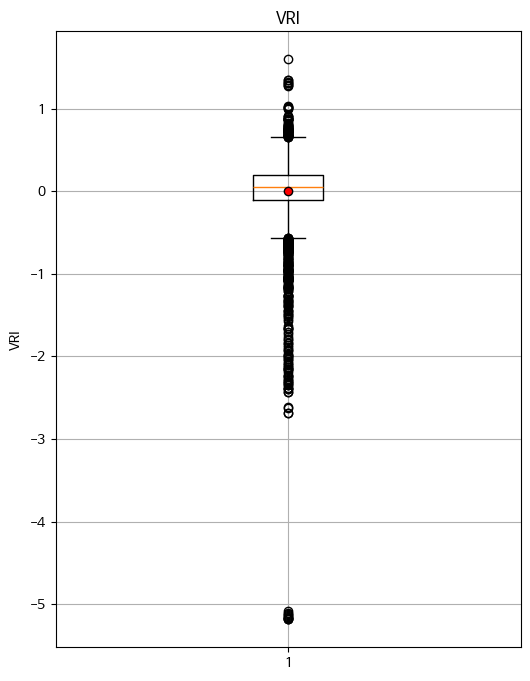

In [ ]:


import matplotlib.pyplot as plt

# final_df 예시
# final_df = pd.DataFrame({
#     'stop_id': [...],
#     'mean_old_level': [...],
# })

# NaN 제거 (건물이 없는 정류장 제외)
subset = filtered_df['VRI']

plt.figure(figsize=(6, 8))
plt.boxplot(subset, vert=True, showmeans=True, meanprops={"marker":"o", "markerfacecolor":"red", "markeredgecolor":"black"})
plt.title("VRI")
plt.ylabel("VRI")
plt.grid(True)
plt.show()


In [ ]:
filtered_df['최종지수'] = filtered_df['VRI']* 0.5 + filtered_df['승차총승객수_std']*0.5
filtered_df['최종지수']

,최종지수
0,0.248649
1,0.603766
2,0.092742
3,0.715295
4,-0.208188
...,...
5906,-1.055469
5907,-0.487025
5908,-0.658206
5909,-0.151583


In [ ]:
df_where = df[['표준버스정류장ID','X좌표','Y좌표']]
df_where

,표준버스정류장ID,X좌표,Y좌표
0,100000001,126.987752,37.569806
1,100000002,126.996521,37.579433
2,100000003,126.998251,37.582580
3,100000004,126.987613,37.568579
4,100000005,127.001744,37.586243
...,...,...,...
10618,124900137,127.147539,37.527911
10619,124900138,127.159941,37.565324
10620,124900139,127.156521,37.557835
10621,124900140,127.156821,37.556380


In [ ]:
df_cluster = filtered_df[['표준버스정류장ID','Exposure','Sensitivity','Adaptive_Capacity','승차총승객수_std','최종지수']]
df_cluster = pd.concat([df_cluster,df_where],axis=1)
df_cluster =df_cluster.dropna()
df_cluster

,표준버스정류장ID,Exposure,Sensitivity,Adaptive_Capacity,승차총승객수_std,최종지수,표준버스정류장ID,X좌표,Y좌표
0,100000001.0,-0.650965,1.653685,-0.244831,0.124203,0.248649,100000001,126.987752,37.569806
1,100000004.0,-0.310634,1.725914,-0.244831,0.731296,0.603766,100000002,126.996521,37.579433
2,100000006.0,-0.298405,0.225847,-0.096693,0.155276,0.092742,100000003,126.998251,37.582580
3,100000007.0,-0.698761,0.232628,-0.096693,1.498777,0.715295,100000004,126.987613,37.568579
4,100000008.0,-0.298405,0.195379,-0.096693,-0.438966,-0.208188,100000005,127.001744,37.586243
...,...,...,...,...,...,...,...,...,...
5906,124900121.0,-1.513155,-0.584515,1.847001,-0.663020,-1.055469,114900042,126.868808,37.540239
5907,124900123.0,-1.238300,-0.727807,0.348779,-0.308133,-0.487025,114900044,126.831971,37.540197
5908,124900124.0,-1.238300,-0.694063,0.348779,-0.658931,-0.658206,114900047,126.871333,37.546695
5909,124900138.0,-1.889273,-0.299719,-0.255412,0.116377,-0.151583,114900048,126.842581,37.518745


## 클러스터링

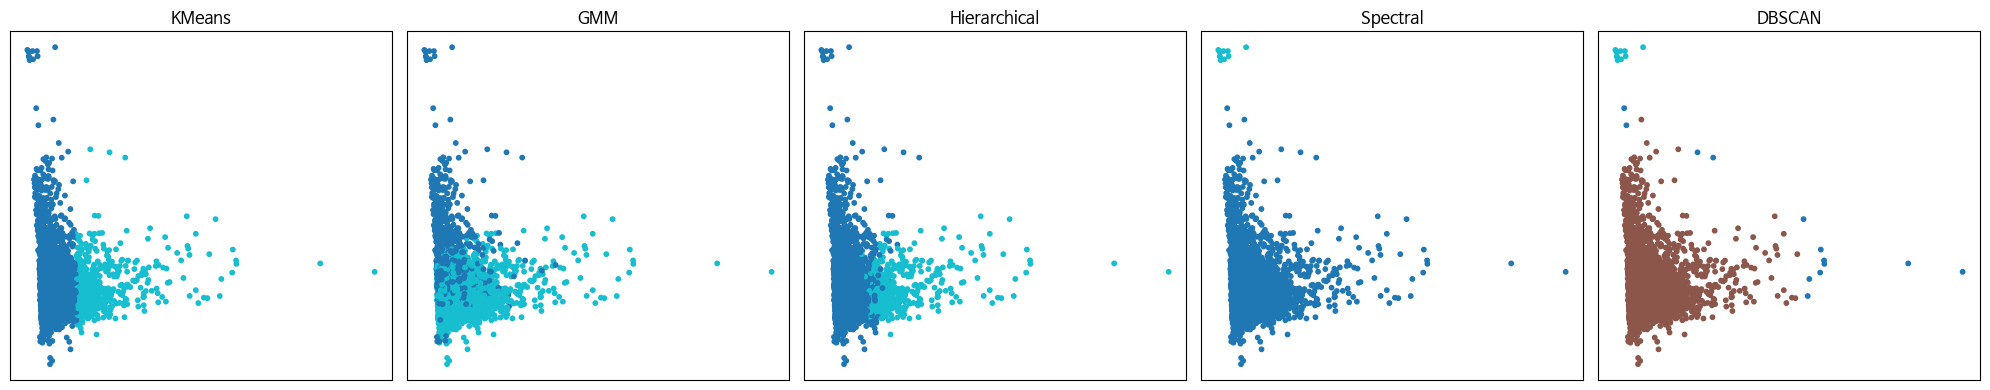


▶ KMeans 클러스터별 최종지수 평균:
KMeans
1    1.266613
0   -0.120790
Name: 최종지수, dtype: float64

▶ GMM 클러스터별 최종지수 평균:
GMM
1    0.063321
0   -0.220149
Name: 최종지수, dtype: float64

▶ Hierarchical 클러스터별 최종지수 평균:
Hierarchical
1    1.269670
0   -0.115032
Name: 최종지수, dtype: float64

▶ Spectral 클러스터별 최종지수 평균:
Spectral
0    0.005284
1   -2.764651
Name: 최종지수, dtype: float64

▶ DBSCAN 클러스터별 최종지수 평균:
DBSCAN
-1    3.634827
 0   -0.002933
 1   -2.764651
Name: 최종지수, dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 클러스터링 대상 변수 지정
features = ['Exposure', 'Sensitivity', 'Adaptive_Capacity', '승차총승객수_std']
X = df_cluster[features].values

# 정규화
scaler = StandardScaler()
X_scaled = X

# PCA 2차원 축소 (시각화용)
X_pca = PCA(n_components=2).fit_transform(X_scaled)

results = {}

# 2. KMeans + GMM + Hierarchical + Spectral: 실루엣 기반 최적 k 탐색
k_range = range(2, 11)
sil_k = {method: [] for method in ['KMeans', 'GMM', 'Hierarchical', 'Spectral']}

for k in k_range:
    # KMeans
    labels = KMeans(n_clusters=k, random_state=42).fit_predict(X_scaled)
    sil_k['KMeans'].append(silhouette_score(X_scaled, labels))
    # GMM
    labels = GaussianMixture(n_components=k, random_state=42).fit_predict(X_scaled)
    sil_k['GMM'].append(silhouette_score(X_scaled, labels))
    # Hierarchical
    labels = AgglomerativeClustering(n_clusters=k).fit_predict(X_scaled)
    sil_k['Hierarchical'].append(silhouette_score(X_scaled, labels))
    # Spectral
    labels = SpectralClustering(n_clusters=k, affinity='nearest_neighbors', random_state=42).fit_predict(X_scaled)
    sil_k['Spectral'].append(silhouette_score(X_scaled, labels))

# 최적 k와 점수 저장
for method in sil_k:
    best_idx = np.argmax(sil_k[method])
    best_k = k_range[best_idx]
    results[method] = (best_k, sil_k[method][best_idx])


"""
# 실루엣 계수로 최적 k 찾기 (KMeans 기준)
sil_scores = []
k_range = range(2, 11)
for k in k_range:
    labels = KMeans(n_clusters=k, random_state=42).fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

best_k = k_range[np.argmax(sil_scores)]
"""

# 클러스터링 알고리즘별 수행
df_cluster['KMeans'] = KMeans(n_clusters=results['KMeans'][0], random_state=42).fit_predict(X_scaled)
df_cluster['GMM'] = GaussianMixture(n_components=results['GMM'][0], random_state=42).fit_predict(X_scaled)
df_cluster['Hierarchical'] = AgglomerativeClustering(n_clusters=results['Hierarchical'][0]).fit_predict(X_scaled)
df_cluster['Spectral'] = SpectralClustering(n_clusters=results['Spectral'][0], affinity='nearest_neighbors', random_state=42).fit_predict(X_scaled)
df_cluster['DBSCAN'] = DBSCAN(eps=1.5, min_samples=10).fit_predict(X_scaled)

# 클러스터 시각화
methods = ['KMeans', 'GMM', 'Hierarchical', 'Spectral', 'DBSCAN']
fig, axes = plt.subplots(1, len(methods), figsize=(20, 4))
for i, method in enumerate(methods):
    axes[i].scatter(X_pca[:, 0], X_pca[:, 1], c=df_cluster[method], cmap='tab10', s=10)
    axes[i].set_title(method)
    axes[i].set_xticks([])
    axes[i].set_yticks([])
plt.tight_layout()
plt.show()

# 클러스터별 최종지수 평균 계산
for method in methods:
    print(f"\n▶ {method} 클러스터별 최종지수 평균:")
    print(df_cluster.groupby(method)['최종지수'].mean().sort_values(ascending=False))




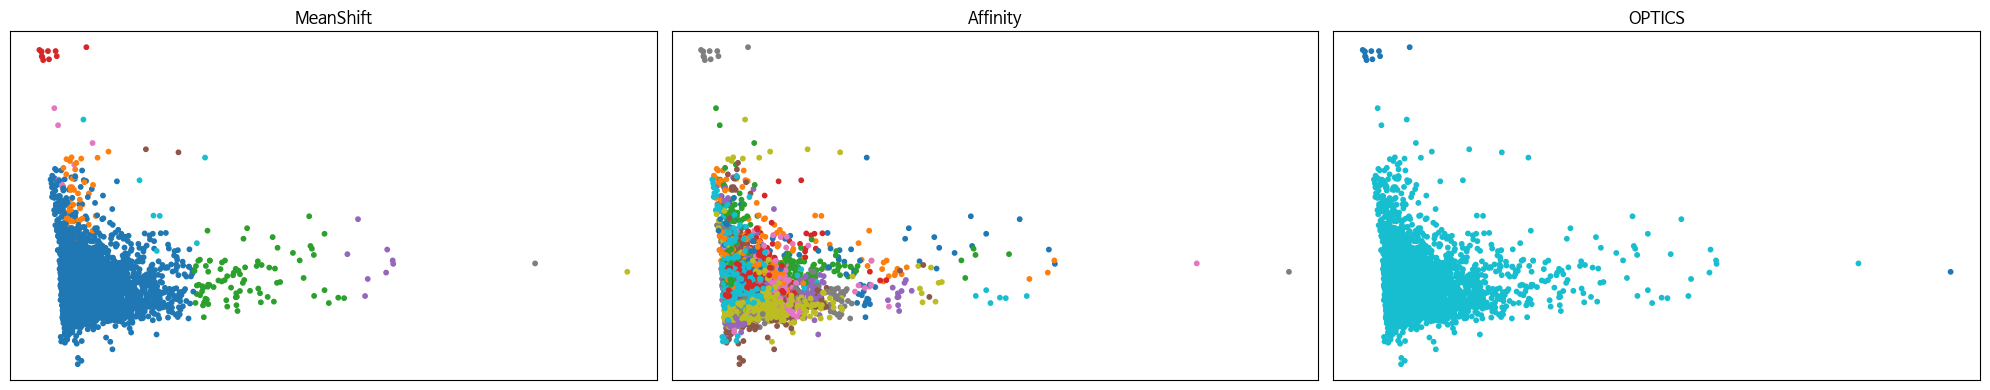


▶ MeanShift 클러스터별 최종지수 평균:
MeanShift
9     8.159920
8     6.942948
5     4.455191
3     2.442043
6     1.756651
11    0.798219
10    0.699172
2     0.184021
0    -0.022708
7    -0.638429
1    -1.009040
4    -2.764651
Name: 최종지수, dtype: float64

▶ Affinity 클러스터별 최종지수 평균:
Affinity
147    8.159920
125    6.942948
29     4.643934
8      4.635885
4      3.808886
         ...   
21    -1.217279
19    -1.265411
178   -1.433532
177   -1.465862
140   -2.764651
Name: 최종지수, Length: 186, dtype: float64

▶ OPTICS 클러스터별 최종지수 평균:
OPTICS
 0    0.003867
-1   -1.854270
Name: 최종지수, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

methods = [ 'MeanShift', 'Affinity', 'OPTICS']


from sklearn.cluster import MeanShift

ms = MeanShift(bin_seeding=True)
ms_labels = ms.fit_predict(X_scaled)
df_cluster['MeanShift'] = ms_labels


from sklearn.cluster import AffinityPropagation

ap = AffinityPropagation(random_state=42, affinity='euclidean')
df_cluster['Affinity'] = ap.fit_predict(X_scaled)

from sklearn.cluster import OPTICS

optics = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.05)
df_cluster['OPTICS'] = optics.fit_predict(X_scaled)



fig, axes = plt.subplots(1, len(methods), figsize=(20, 4))
for ax, method in zip(axes, methods):
    sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=df_cluster[method], cmap='tab10', s=10)
    ax.set_title(method)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

# 각 클러스터링 기법별 '최종지수' 평균
for method in methods:
    print(f"\n▶ {method} 클러스터별 최종지수 평균:")
    print(df_cluster.groupby(method)['최종지수'].mean().sort_values(ascending=False))


In [ ]:
df_cluster

,표준버스정류장ID,Exposure,Sensitivity,Adaptive_Capacity,승차총승객수_std,최종지수,표준버스정류장ID,X좌표,Y좌표,KMeans,GMM,Hierarchical,Spectral,DBSCAN,MeanShift,Affinity,OPTICS
0,100000001.0,-0.650965,1.653685,-0.244831,0.124203,0.248649,100000001,126.987752,37.569806,0,0,0,0,0,0,59,0
1,100000004.0,-0.310634,1.725914,-0.244831,0.731296,0.603766,100000002,126.996521,37.579433,0,0,0,0,0,0,59,0
2,100000006.0,-0.298405,0.225847,-0.096693,0.155276,0.092742,100000003,126.998251,37.582580,0,1,0,0,0,0,64,0
3,100000007.0,-0.698761,0.232628,-0.096693,1.498777,0.715295,100000004,126.987613,37.568579,1,1,1,0,0,0,51,0
4,100000008.0,-0.298405,0.195379,-0.096693,-0.438966,-0.208188,100000005,127.001744,37.586243,0,1,0,0,0,0,65,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5906,124900121.0,-1.513155,-0.584515,1.847001,-0.663020,-1.055469,114900042,126.868808,37.540239,0,0,0,0,0,1,6,0
5907,124900123.0,-1.238300,-0.727807,0.348779,-0.308133,-0.487025,114900044,126.831971,37.540197,0,0,0,0,0,0,183,0
5908,124900124.0,-1.238300,-0.694063,0.348779,-0.658931,-0.658206,114900047,126.871333,37.546695,0,0,0,0,0,0,183,0
5909,124900138.0,-1.889273,-0.299719,-0.255412,0.116377,-0.151583,114900048,126.842581,37.518745,0,1,0,0,0,0,182,0


## 시각화

In [ ]:
import folium
cluster_means = df_cluster.groupby('MeanShift')['최종지수'].mean()
best_cluster = cluster_means.idxmax()

# 해당 클러스터 소속 정류장 중 '최종지수' 최대값 정류장 선택
best_station = df_cluster[df_cluster['MeanShift'] == best_cluster].loc[
    df_cluster['최종지수'].idxmax()
]

# 좌표 추출 (Y: 위도, X: 경도)
lat, lon = best_station['Y좌표'], best_station['X좌표']


m = folium.Map(location=[lat, lon], zoom_start=16, tiles="OpenStreetMap")


# 중심 정류장 마커 강조
folium.Marker(
    location=[lat, lon],
    popup=f"Best Station\nID: {best_station['표준버스정류장ID']}\n평균 최종지수: {cluster_means[best_cluster]:.1f}",
    icon=folium.Icon(color='red', icon='star')
).add_to(m)


folium.Circle(
    location=[lat, lon],
    radius=400,  # 단위: meters
    color='red',
    weight=2,
    fill=False
).add_to(m)

m

In [ ]:
import folium
import pandas as pd
import matplotlib.pyplot as plt
from folium.plugins import MarkerCluster
from matplotlib import cm

# MeanShift 클러스터별로 최종지수 최대값을 가진 행 추출
top_by_cluster = (
    df_cluster[['표준버스정류장ID', 'Y좌표', 'X좌표', 'MeanShift', '최종지수']]
    .groupby('MeanShift', dropna=False, as_index=False)
    .apply(lambda grp: grp.loc[grp['최종지수'].idxmax()])
    .reset_index(drop=True)
)

center_lat = df_cluster['Y좌표'].mean()
center_lon = df_cluster['X좌표'].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles='OpenStreetMap')


# 각 클러스터의 정류장만 지도에 표시
for _, row in top_by_cluster.iterrows():
    folium.CircleMarker(
        location=[row['Y좌표'], row['X좌표']],
        radius=6,
        fill=True,
        fill_opacity=0.9,
        popup=(f"ID: {row['표준버스정류장ID']}<br>"
               f"클러스터: {row['MeanShift']}<br>"
               f"최종지수: {row['최종지수']:.2f}")
    ).add_to(m)


m.add_child(folium.LayerControl())


display(m)

In [ ]:
import folium
from folium.plugins import MarkerCluster
import pandas as pd

methods = ['KMeans', 'GMM', 'Hierarchical', 'Spectral', 'MeanShift', 'Affinity', 'OPTICS']


top_by_method = {}
for m in methods:
    if m not in df_cluster.columns:
        continue
    df_m = (
        df_cluster
        [[ '표준버스정류장ID', 'Y좌표', 'X좌표', m, '최종지수' ]]
        .dropna(subset=[m, '최종지수'])
    )
    idxs = df_m.groupby(m)['최종지수'].idxmax()
    top_by_method[m] = df_m.loc[idxs].reset_index(drop=True)


center_lat = df_cluster['Y좌표'].mean()
center_lon = df_cluster['X좌표'].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles='OpenStreetMap')

method_colors = {
    'KMeans': 'red',
    'GMM': 'orange',
    'Hierarchical': 'green',
    'Spectral': 'purple',
    'MeanShift': 'blue',
    'Affinity': 'yellow',
    'OPTICS': 'darkred'
}

for mtd, df_top in top_by_method.items():
    cluster = MarkerCluster(name=mtd).add_to(m)
    color = method_colors.get(mtd, 'black')
    for _, row in df_top.iterrows():
        folium.CircleMarker(
            location=[row['Y좌표'], row['X좌표']],
            radius=7,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.8,
            popup=(
                f"<b>방식:</b> {mtd}<br>"
                f"클러스터: {row[mtd]}<br>"
                f"ID: {row['표준버스정류장ID']}<br>"
                f"최종지수: {row['최종지수']:.3f}"
            )
        ).add_to(cluster)

folium.LayerControl(collapsed=False).add_to(m)


display(m)


